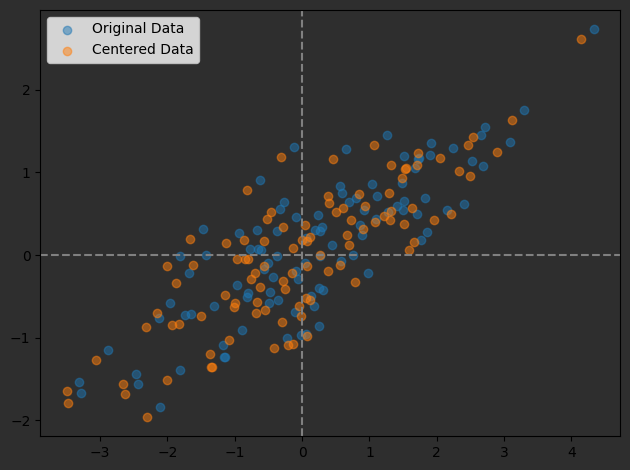

In [14]:
import os

import matplotlib.pyplot as plt
import numpy as np

# Generate a synthetic dataset for PCA
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]  # covariance matrix
X = np.random.multivariate_normal(mean, cov, 100)

# Compute the mean and center the data
mu = np.mean(X, axis=0)
X_centered = X - mu

# Compute the covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
order = eig_vals.argsort()[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

# Project data onto the first principal component
X_proj = X_centered @ eig_vecs[:, :2]

# Start with the centered data plot
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X[:, 0], X[:, 1], alpha=0.5, label="Original Data")
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.5, label="Centered Data")
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.legend()
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/centered_data.png")


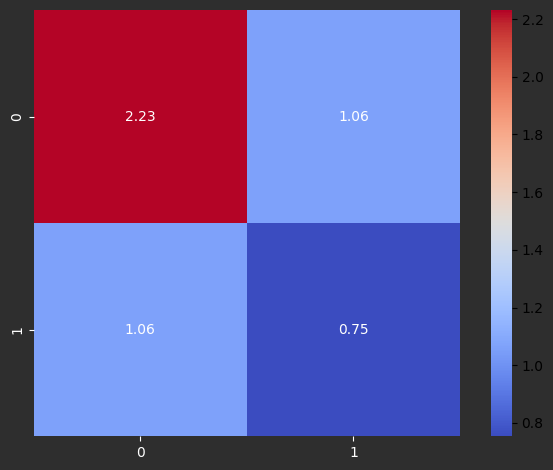

In [23]:
import seaborn as sns

# Plot covariance matrix heatmap
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
plt.tight_layout()
plt.tight_layout()
ax.tick_params(colors='white')
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Covariance-Matrix-Heatmap.png")

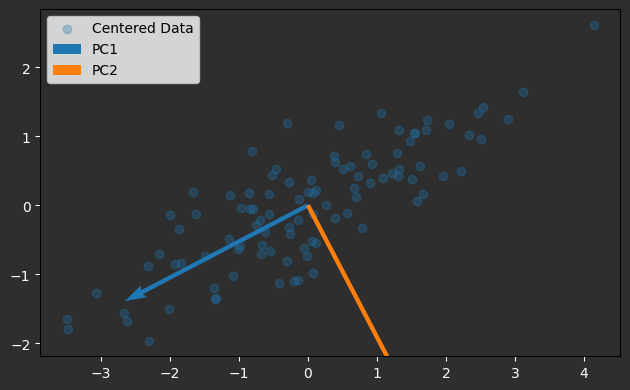

In [22]:
# Visualizing eigenvectors on the centered data
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X_centered[:, 0], X_centered[:, 1], alpha=0.3, label="Centered Data")
origin = np.mean(X_centered, axis=0)

# Draw the first two eigenvectors
for i in range(2):
    vec = eig_vecs[:, i]
    ax.quiver(*origin, *vec * 3, angles='xy', scale_units='xy', scale=1, color=f"C{i}", label=f"PC{i + 1}")

ax.set_aspect('equal')
ax.tick_params(colors='white')

ax.legend()
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Principal-Components-as-Eigenvectors.png")

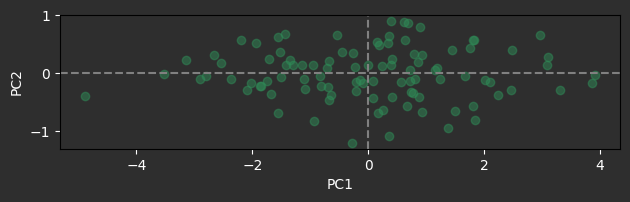

In [21]:
# Plot the projected data onto the first two principal components
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Dark grey figure background
ax.set_facecolor('#2e2e2e')  # Dark grey axes background
ax.scatter(X_proj[:, 0], X_proj[:, 1], alpha=0.5, color="seagreen")
ax.axhline(0, color='gray', linestyle='--')
ax.axvline(0, color='gray', linestyle='--')
ax.set_xlabel("PC1", color='white')
ax.set_ylabel("PC2", color='white')
ax.tick_params(colors='white')
ax.set_aspect('equal')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Data Projected-onto-First-Two-Principal-Components.png")

<Figure size 640x480 with 0 Axes>

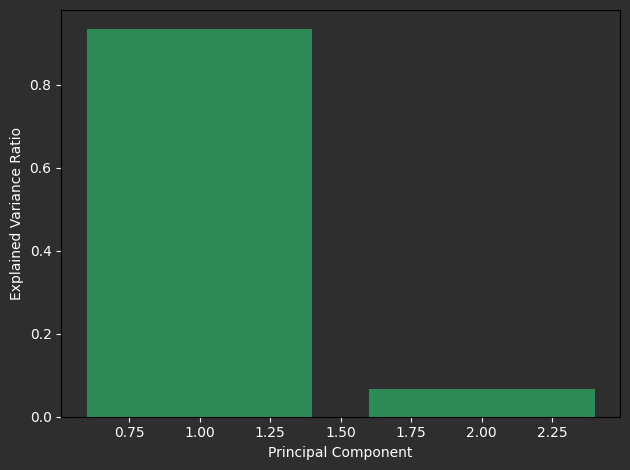

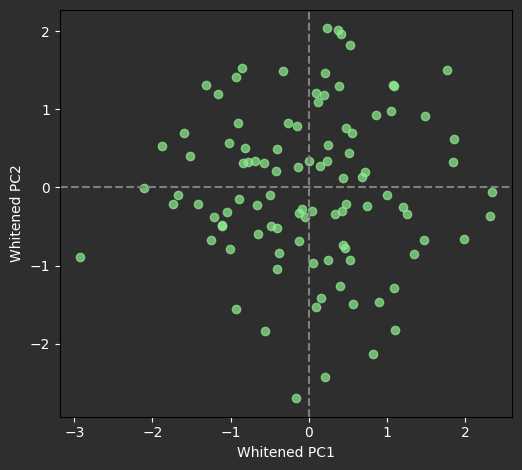

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data (as before)
np.random.seed(42)
mean = [0, 0]
cov = [[3, 1.5], [1.5, 1]]
X = np.random.multivariate_normal(mean, cov, 100)
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.cov(X_centered, rowvar=False)

# Eigen decomposition
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

# Project and reconstruct using top 1 component
V_k = eig_vecs[:, :1]
Z = X_centered @ V_k
X_reconstructed = Z @ V_k.T

# Whitening
Lambda_inv_sqrt = np.diag(1.0 / np.sqrt(eig_vals))
X_white = X_centered @ eig_vecs @ Lambda_inv_sqrt

# ----------------- Slide 5: Scree Plot -----------------
plt.figure(facecolor='#2e2e2e')
fig1, ax1 = plt.subplots()
fig1.patch.set_facecolor('#2e2e2e')
ax1.set_facecolor('#2e2e2e')

explained_variance_ratio = eig_vals / np.sum(eig_vals)
ax1.bar(range(1, len(eig_vals) + 1), explained_variance_ratio, color='seagreen')
ax1.set_xlabel('Principal Component', color='white')
ax1.set_ylabel('Explained Variance Ratio', color='white')
ax1.tick_params(colors='white')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/Scree-Plot.png")
# ----------------- Slide 6: Whitening -----------------
fig2, ax2 = plt.subplots()
fig2.patch.set_facecolor('#2e2e2e')
ax2.set_facecolor('#2e2e2e')

ax2.scatter(X_white[:, 0], X_white[:, 1], alpha=0.7, color='lightgreen')
ax2.axhline(0, color='gray', linestyle='--')
ax2.axvline(0, color='gray', linestyle='--')
ax2.set_xlabel('Whitened PC1', color='white')
ax2.set_ylabel('Whitened PC2', color='white')
ax2.tick_params(colors='white')
ax2.set_aspect('equal')
plt.tight_layout()
if not os.path.exists('../../output/figures/'):
    os.makedirs('../../output/figures/')
plt.savefig("../../output/figures/whitening.png")

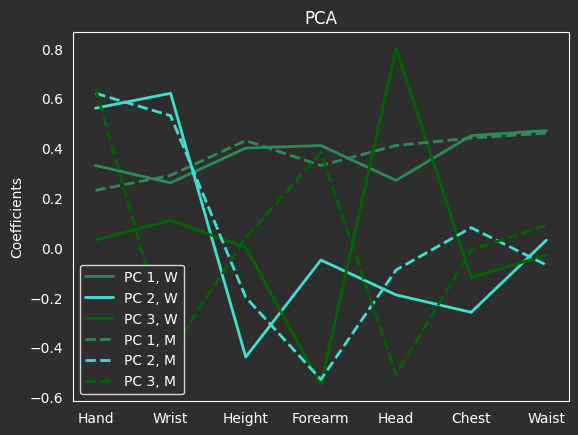

In [14]:
import matplotlib.pyplot as plt

# Define x and y values for each horizontal line
x1 = [0, 1, 2, 3, 4, 5, 6]
y1 = [0.33, 0.26, 0.40, 0.41, 0.27, 0.45, 0.47]

x2 = [0, 1, 2, 3, 4, 5, 6]
y2 = [0.56, 0.62, -0.44, -0.05, -0.19, -0.26, 0.03]

x3 = [0, 1, 2, 3, 4, 5, 6]
y3 = [0.03, 0.11, -0.00, -0.55, 0.80, -0.12, -0.03]

x4 = [0, 1, 2, 3, 4, 5, 6]
y4 = [0.23, 0.29, 0.43, 0.33, 0.41, 0.44, 0.46]

x5 = [0, 1, 2, 3, 4, 5, 6]
y5 = [0.62, 0.53, -0.20, -0.53, -0.09, 0.08, -0.07]

x6 = [0, 1, 2, 3, 4, 5, 6]
y6 = [0.64, -0.42, 0.04, 0.38, -0.51, -0.01, 0.09]

# Create the plot
# Create figure and axis
fig, ax = plt.subplots()
fig.patch.set_facecolor('#2e2e2e')  # Outer background
ax.set_facecolor('#2e2e2e')  # Plot area background

# Plot each line
plt.plot(x1, y1, linewidth=2, color='seagreen', label='PC 1, W')
plt.plot(x2, y2, label='PC 2, W', linewidth=2, color='turquoise')
plt.plot(x3, y3, label='PC 3, W', linewidth=2, color='darkgreen')

plt.plot(x4, y4, label='PC 1, M', linewidth=2, color='seagreen', linestyle='--')
plt.plot(x5, y5, label='PC 2, M', linewidth=2, color='turquoise', linestyle='--')
plt.plot(x6, y6, label='PC 3, M', linewidth=2, color='darkgreen', linestyle='--')

# Add labels and title
plt.ylabel('Coefficients', color='white')
tick_positions = [0, 1, 2, 3, 4, 5, 6]
tick_labels = ['Hand', 'Wrist', 'Height', 'Forearm', 'Head', 'Chest', 'Waist']
plt.xticks(tick_positions, tick_labels, color='white')  # Light tick labels

# Light y-ticks as well
plt.yticks(color='white')
plt.title('PCA')
# Legend with light text
legend = ax.legend(facecolor='#2e2e2e', edgecolor='white')
for text in legend.get_texts():
    text.set_color("white")
ax.grid(False)

# Show the plot
plt.savefig("../../output/figures/PCA_example.png")
